In [1]:
import MetaTrader5 as mt5
from datetime import datetime
import pandas as pd
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor
import optuna
import numpy as np
from stable_baselines3.common.evaluation import evaluate_policy
import gymnasium as gym
from gymnasium import spaces
import gc
from wandb.integration.sb3 import WandbCallback
import wandb
from alibi_detect.od import IForest
from stable_baselines3.common.callbacks import BaseCallback
import torch
import os
from stable_baselines3.common.callbacks import EvalCallback
import matplotlib.pyplot as plt
import random
import time

d:\dev\dev python\OrionTrader\.venv\lib\site-packages\pydantic\_internal\_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
d:\dev\dev python\OrionTrader\.venv\lib\site-packages\pydantic\_internal\_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` 

## Config

In [2]:
MT5_LOGIN = int(os.environ.get('MT5_LOGIN'))
MT5_PASSWORD = os.environ.get('MT5_PASSWORD')
MT5_SERVER = os.environ.get('MT5_SERVER')
SYMBOL = "EURUSD"
TIMEFRAME = mt5.TIMEFRAME_D1
START = datetime(2020,1,1)
END = datetime(2023,1,1)
MODEL_PATH = "models/best_ppo_forex.zip"
RESUME_TIMESTEPS = 100_000

## Connexion MT5 et récupération historique

In [3]:
def connect_mt5(max_retries=3, wait_time=2):
    print("🔹 Fermeture d'éventuelles connexions précédentes...")
    mt5.shutdown()
    time.sleep(1)

    for attempt in range(1, max_retries + 1):
        print(f"\n🔄 Tentative {attempt}/{max_retries} d'initialisation de MetaTrader 5...")
        if not mt5.initialize():
            err = mt5.last_error()
            print(f"❌ Échec de l'initialisation : {err}")
            time.sleep(wait_time)
            continue

        mt5_version = mt5.version()
        print(f"✅ MetaTrader 5 initialisé : version {mt5_version}")

        if MT5_LOGIN:
            if not mt5.login(login=MT5_LOGIN, password=MT5_PASSWORD, server=MT5_SERVER):
                err = mt5.last_error()
                print(f"❌ Connexion échouée : {err}")
                mt5.shutdown()
                time.sleep(wait_time)
                continue
            print("✅ Connexion réussie à MetaTrader 5.")
        return True

    return False

# Connexion et récupération des données
if connect_mt5():
    df_mt5 = pd.DataFrame(mt5.copy_rates_range(SYMBOL, TIMEFRAME, START, END))
    print(f"✅ {len(df_mt5)} barres téléchargées")
else:
    raise Exception("❌ Impossible de se connecter à MT5")

🔹 Fermeture d'éventuelles connexions précédentes...

🔄 Tentative 1/3 d'initialisation de MetaTrader 5...
✅ MetaTrader 5 initialisé : version (500, 5370, '17 Oct 2025')
✅ Connexion réussie à MetaTrader 5.
✅ 780 barres téléchargées


## Créer env compatible déjà utilisé dans notebook

In [ ]:
#verif
class ForexEnv(gym.Env):
    def __init__(self, df):
        super(ForexEnv, self).__init__()
        self.df = df.reset_index(drop=True)
        self.max_steps = len(self.df) - 1
        self.current_step = 0

        self.balance = 10000.0
        self.entry_price = 0.0

        # Actions : 0 = hold, 1 = buy, 2 = sell, (optionnel 3 = close)
        # Ajustez Discrete(3) ou Discrete(4) selon votre modèle entraîné.
        self.action_space = spaces.Discrete(3)

        # Observation : prix actuel et delta précédent
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(2,), dtype=np.float32)

        self.position = 0  # 0 = neutral, 1 = long, -1 = short

    def _col(self):
        # Supporte 'close' ou 'Close' suivant votre dataframe
        return 'close' if 'close' in self.df.columns else ('Close' if 'Close' in self.df.columns else None)

    def reset(self, **kwargs):
        self.current_step = 0
        self.position = 0
        self.entry_price = 0.0
        self.balance = 10000.0
        obs = self._next_obs()
        info = {}
        return obs, info

    def _next_obs(self):
        col = self._col()
        if col is None:
            raise KeyError("Aucune colonne 'close' ou 'Close' dans le dataframe")
        price = float(self.df.loc[self.current_step, col])
        delta = float(self.df.loc[self.current_step, col] - self.df.loc[self.current_step - 1, col]) if self.current_step > 0 else 0.0
        return np.array([price, delta], dtype=np.float32)

    def step(self, action):
        # Normalize action (accepte scalaire np.int64, array, list...)
        try:
            a = np.asarray(action).flatten()[0]
            action = int(a)
        except Exception:
            action = int(action)

        col = self._col()
        if col is None:
            raise KeyError("Aucune colonne 'close' ou 'Close' dans le dataframe")

        prev_price = float(self.df.loc[self.current_step, col])
        self.current_step += 1
        terminated = self.current_step >= len(self.df) - 1
        price = float(self.df.loc[self.current_step, col])
        delta = price - prev_price

        # Apply action
        if action == 1:
            self.position = 1
            self.entry_price = price
        elif action == 2:
            self.position = -1
            self.entry_price = price
        elif action == 0:
            # hold : ne change pas la position
            pass
        else:
            # si vous utilisez action 3 (close), gérez ici
            self.position = 0

        pnl = delta * self.position * 1000.0
        self.balance += pnl

        reward = float(pnl)  # reward lié au PnL
        obs = np.array([price, delta], dtype=np.float32)
        info = {}
        truncated = False
        return obs, reward, terminated, truncated, info

    def get_info(self):
        col = self._col()
        cur_price = float(self.df.loc[self.current_step, col]) if col else None
        return {
            "balance": self.balance,
            "position": self.position,
            "current_price": cur_price
        }

In [5]:
class RandomStartWrapper(gym.Wrapper):
    def __init__(self, env, min_offset=1, max_offset=None):
        super().__init__(env)
        self.min_offset = min_offset
        self.max_offset = max_offset

    def reset(self, **kwargs):
        max_off = self.max_offset if self.max_offset is not None else max(1, self.env.unwrapped.max_steps // 10)
        self.env.unwrapped.current_step = random.randint(self.min_offset, max_off)
        return self.env.reset(**kwargs)

class EquityVisualizerCallback(BaseCallback):
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.equity = []
        self.positions = []
        self.prices = []
        
    def _on_step(self):
        env = self.training_env.envs[0].unwrapped
        self.equity.append(env.balance)
        self.positions.append(env.position)
        self.prices.append(env.df.loc[env.current_step, 'close'])
        return True

    def plot_results(self):
        plt.figure(figsize=(12, 8))
        plt.subplot(2,1,1)
        plt.plot(self.equity)
        plt.title('Equity Curve')
        
        plt.subplot(2,1,2)
        plt.plot(self.prices, color='gray', alpha=0.6)
        for i in range(len(self.positions)):
            if self.positions[i] == 1:
                plt.axvspan(i, i+1, color='green', alpha=0.3)
            elif self.positions[i] == -1:
                plt.axvspan(i, i+1, color='red', alpha=0.3)
        plt.title('Prix et Positions')
        plt.tight_layout()
        plt.show()

In [6]:
def train_with_monitoring(model, env, total_timesteps, initial_balance=10000, seed=None, extra_callbacks=None):
    """Entraînement avec monitoring détaillé"""
    
    # Initialisation des seeds pour reproductibilité
    if seed is not None:
        torch.manual_seed(seed)
        np.random.seed(seed)
        
    # Callbacks
    equity_viz = EquityVisualizerCallback()
    callbacks = [equity_viz]
    
    if extra_callbacks:
        callbacks += extra_callbacks
    
    # Évaluation initiale
    print("\n📊 Performance initiale :")
    mean_reward, std_reward = evaluate_policy(model, env, n_eval_episodes=5)
    print(f"Reward moyenne: {mean_reward:.2f} ± {std_reward:.2f}")
    print(f"Balance initiale: {initial_balance:.2f}")
    
    # Entraînement avec monitoring
    print("\n🏋️ Début de l'entraînement...")
    model.learn(
        total_timesteps=total_timesteps,
        callback= callbacks
    )
    
    # Évaluation finale
    print("\n📊 Performance finale :")
    mean_reward, std_reward = evaluate_policy(model, env, n_eval_episodes=5)
    print(f"Reward moyenne: {mean_reward:.2f} ± {std_reward:.2f}")
    
    # Statistiques de trading
    final_balance = equity_viz.equity[-1]
    profit_pct = ((final_balance - initial_balance) / initial_balance) * 100
    
    print(f"\n💰 Statistiques de trading:")
    print(f"Balance initiale: {initial_balance:.2f}")
    print(f"Balance finale: {final_balance:.2f}")
    print(f"Profit/Perte: {profit_pct:.2f}%")
    
    # Visualisations
    plt.figure(figsize=(15, 10))
    
    # Equity curve
    plt.subplot(3, 1, 1)
    plt.plot(equity_viz.equity, label='Portfolio Value', color='blue')
    plt.axhline(y=initial_balance, color='r', linestyle='--', label='Initial Balance')
    plt.title('Equity Curve')
    plt.grid(True)
    plt.legend()
    
    # Prix et positions
    plt.subplot(3, 1, 2)
    plt.plot(equity_viz.prices, color='gray', alpha=0.6, label='Price')
    for i in range(len(equity_viz.positions)):
        if equity_viz.positions[i] == 1:  # Long
            plt.axvspan(i, i+1, color='green', alpha=0.3)
        elif equity_viz.positions[i] == -1:  # Short
            plt.axvspan(i, i+1, color='red', alpha=0.3)
    plt.title('Prix et Positions')
    plt.legend()
    plt.grid(True)
    
    # Distribution des profits
    plt.subplot(3, 1, 3)
    returns = np.diff(equity_viz.equity)
    plt.hist(returns, bins=50, color='blue', alpha=0.7)
    plt.axvline(x=0, color='r', linestyle='--')
    plt.title('Distribution des Profits/Pertes')
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    return model

In [7]:
def detect_hallucinations(model, env, n_steps=5000, threshold=0.05):
    """
    Détecte les comportements anormaux du modèle RL (hallucinations d'actions)
    Compatible Gym / Gymnasium / VecEnv
    """
    print("\n🔍 Analyse des comportements du modèle...")

    def step_env(env, action):
        """Compatibilité Gym / Gymnasium / SB3 VecEnv"""
        result = env.step(action)
        if len(result) == 5:
            obs, reward, terminated, truncated, info = result
            done = terminated[0] or truncated[0]
        elif len(result) == 4:
            obs, reward, done, info = result
        else:
            raise ValueError(f"Résultat step inattendu: {len(result)} éléments")
        return obs, reward, done, info

    try:
        # Initialisation
        obs = env.reset()
        if isinstance(obs, tuple):
            obs = obs[0]

        actions, rewards = [], []

        for _ in range(n_steps):
            # Prédiction d'action
            action, _ = model.predict(obs, deterministic=False)

            # Conversion pour compatibilité VecEnv
            if isinstance(action, np.ndarray):
                action = action.item()
            action_vec = np.array([action])

            # Avancer dans l'environnement
            try:
                next_obs, reward, done, _ = step_env(env, action_vec)
                obs = next_obs
                actions.append(action)
                rewards.append(reward[0])

                if done:
                    obs = env.reset()
                    if isinstance(obs, tuple):
                        obs = obs[0]

            except Exception as e:
                print(f"⚠️ Erreur pendant step: {e}")
                break

        if not actions:
            print("❌ Aucune action collectée — vérifie que le modèle et l'env fonctionnent correctement.")
            return None

        # Conversion en array pour analyse
        actions = np.array(actions).reshape(-1, 1)
        rewards = np.array(rewards)

        # Isolation Forest pour détection d'anomalies
        od = IForest(threshold=threshold)
        od.fit(actions)
        preds = od.predict(actions)

        anomaly_ratio = preds["data"]["is_outlier"].mean()
        print(f"\n⚠️ Ratio d'anomalies (risque d'hallucination): {anomaly_ratio:.2%}")

        if anomaly_ratio > 0.1:
            print("🚨 Possible hallucination détectée — comportements incohérents.")
        else:
            print("✅ Comportement du modèle stable et cohérent.")

        # Statistiques supplémentaires
        print("\n📊 Statistiques des actions:")
        unique_actions = np.unique(actions)
        print(f"Actions uniques: {unique_actions}")
        print("Distribution des actions :")
        for a in unique_actions:
            count = np.sum(actions == a)
            print(f"  Action {a}: {count} fois ({count/len(actions)*100:.1f}%)")

        return anomaly_ratio

    except Exception as e:
        print(f"❌ Erreur lors de la détection: {e}")
        return None


## model

🚀 Démarrage de l'entraînement avec monitoring...

📊 Performance initiale :
Reward moyenne: 0.00 ± 0.00
Balance initiale: 10000.00

🏋️ Début de l'entraînement...
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 779      |
|    ep_rew_mean     | -135     |
| time/              |          |
|    fps             | 1581     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 1024     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 779          |
|    ep_rew_mean          | -54.6        |
| time/                   |              |
|    fps                  | 1185         |
|    iterations           | 2            |
|    time_elapsed         | 1            |
|    total_timesteps      | 2048         |
| train/                  |              |
|    approx_kl            | 0.0004649494 |
|    clip_fraction        

C:\Users\Aurelien\AppData\Local\Temp\ipykernel_36524\828217667.py:74: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
d:\dev\dev python\OrionTrader\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


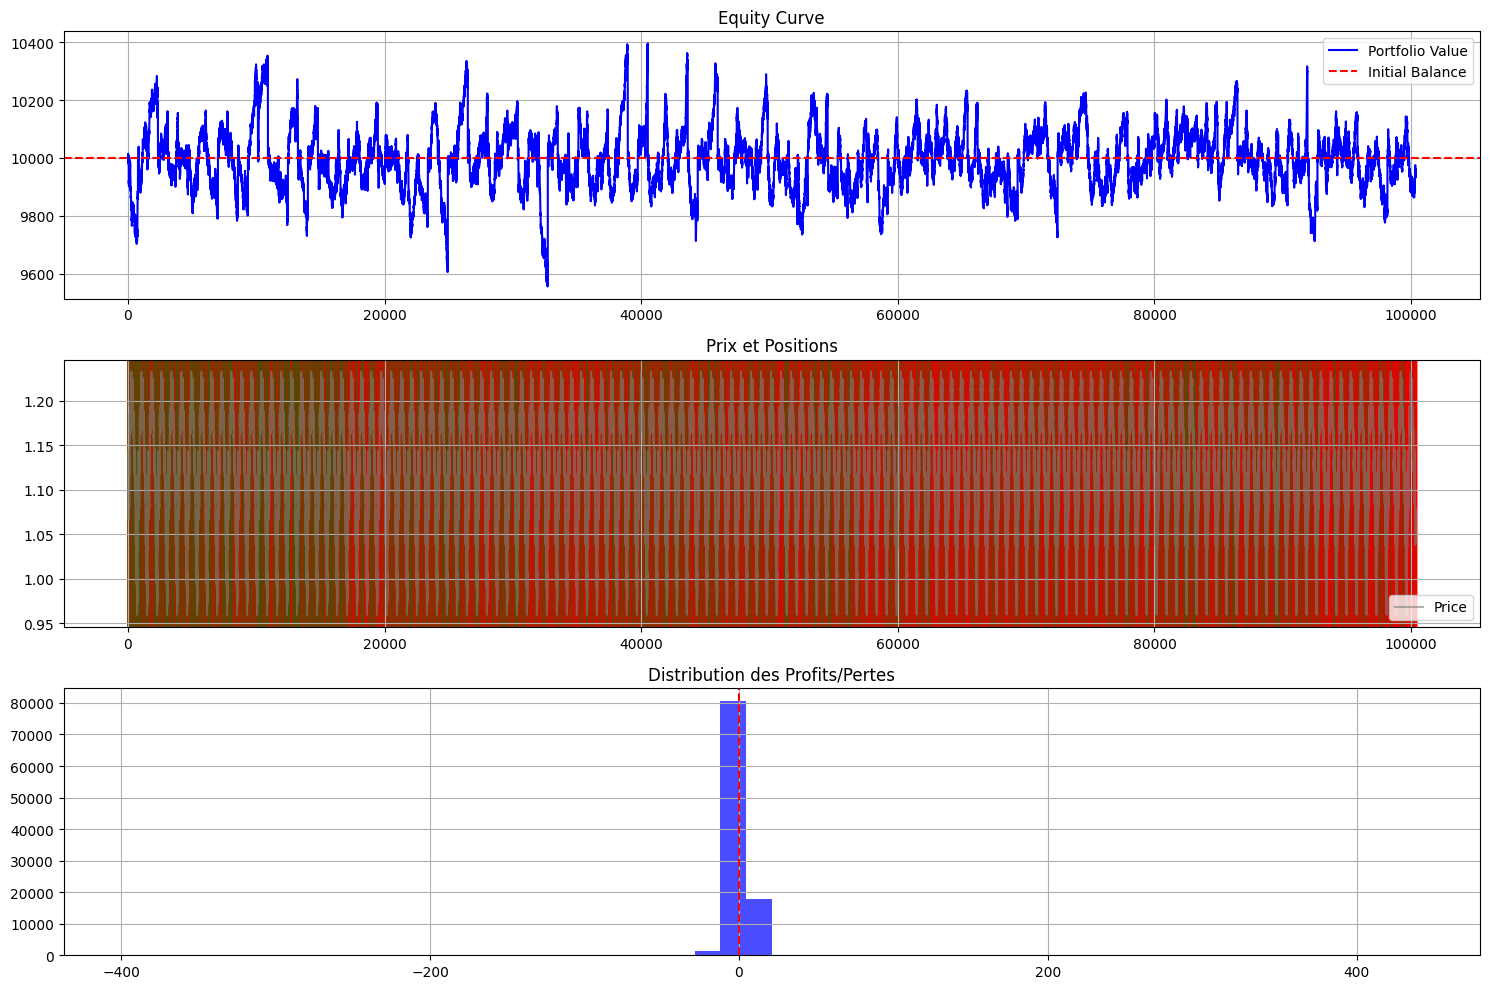


🔍 Analyse des comportements du modèle...

⚠️ Ratio d'anomalies (risque d'hallucination): 6.48%
✅ Comportement du modèle stable et cohérent.

📊 Statistiques des actions:
Actions uniques: [0 1 2]
Distribution des actions :
  Action 0: 3404 fois (68.1%)
  Action 1: 324 fois (6.5%)
  Action 2: 1272 fois (25.4%)

✅ Modèle sauvegardé


True

In [8]:
# Utilisation
SEED = 42
initial_balance = 10000

# Création des environnements
env = DummyVecEnv([lambda: Monitor(RandomStartWrapper(ForexEnv(df_mt5)))])
eval_env = DummyVecEnv([lambda: Monitor(RandomStartWrapper(ForexEnv(df_mt5)))])

# Ajout du callback d'évaluation
eval_callback = EvalCallback(
    eval_env,
    best_model_save_path="models/eval_mt5",
    log_path="logs",
    eval_freq=10_000,
    n_eval_episodes=5,
    deterministic=True
)

# Chargement du modèle
best_model = PPO.load(MODEL_PATH, env=env)

print("🚀 Démarrage de l'entraînement avec monitoring...")
best_model = train_with_monitoring(
    best_model,
    env,
    total_timesteps=RESUME_TIMESTEPS,
    initial_balance=initial_balance,
    seed=SEED,
    extra_callbacks=[eval_callback]
)

# Test de détection d'hallucinations
detect_hallucinations(best_model, env)

# Sauvegarde
best_model.save("models/metatrader_ppo_final.zip")
print("\n✅ Modèle sauvegardé")

# Nettoyage
env.close()
eval_env.close()
mt5.shutdown()